In [48]:
import pandas as pd
from prophet import Prophet

In [73]:
df = pd.read_csv("data/coolrevolution実績.csv", parse_dates=["受注_伝票登録日付"])
df = df.rename(columns={"受注_伝票登録日付": "date", "売上金額": "sales"})
df["day"] = df.date.dt.date

In [74]:
# hly sales
sales = df.groupby(pd.Grouper(key='date', freq='MS')).sales.sum()

In [82]:
# df.groupby(pd.Grouper(key='date', freq='MS'))['請求済数量'].sum().plot()

In [60]:
data = pd.DataFrame(sales).reset_index()
data = data.rename(columns={"date": "ds", "sales": 'y'})

NameError: name 'pd' is not defined

In [61]:
model = Prophet(
    yearly_seasonality=True,   # 年次の季節性
    weekly_seasonality=False,  # 週次の季節性は月次データには不要
    daily_seasonality=False    # 日次の季節性も不要
)

model.fit(data)

18:48:28 - cmdstanpy - INFO - Chain [1] start processing
18:48:29 - cmdstanpy - INFO - Chain [1] done processing


<Axes: >

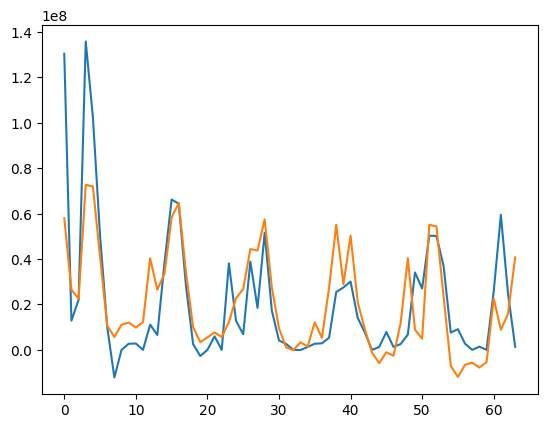

In [70]:
# 在庫

data.y.plot()
model.predict()['yhat'].plot()